In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import scipy 
from edes.modules.detection.detection_utils import plot, plot_ax, plot_errbar, big_plt_font
big_plt_font()

--- Fitted Parameters ---
Inductance (L): 3.0829e-07 H (308.29 nH)
Residual Capacitance (C_res): 1.7157e-12 F (1.72 pF)


/tmp/ipykernel_607434/4197041280.py:15: RuntimeWarning: invalid value encountered in sqrt
  return 1.0 / (2 * np.pi * np.sqrt(L * (c + C_res)))


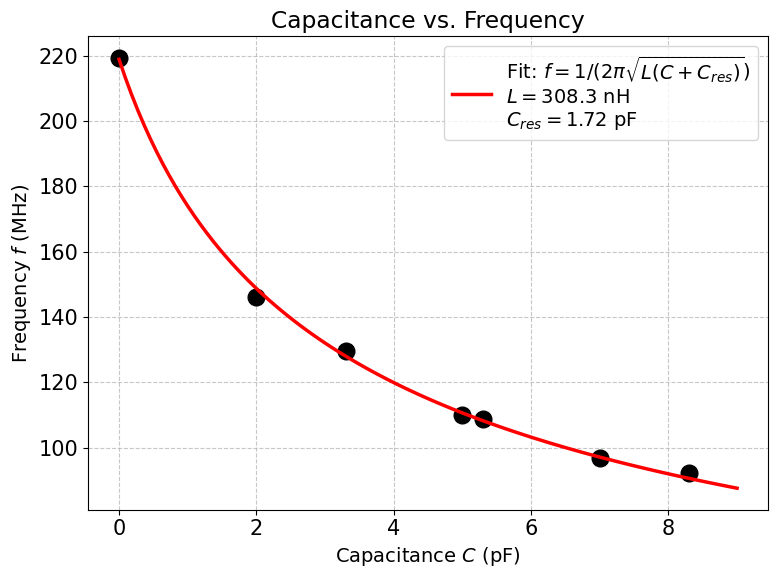

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Extract data from "image_d363ce.png"
C_pF = np.array([0, 2, 3.3, 5, 5.3, 7, 8.3])      # Capacitance in pF
f_MHz = np.array([219.3, 146, 129.6, 110.1, 108.6, 96.7, 92.2]) # Frequency in MHz

# Convert to SI units (Farads and Hertz) for accurate parameter calculation
C_si = C_pF * 1e-12
f_si = f_MHz * 1e6

# 2. Define the corrected fitting function (including 2*pi)
def fit_function(c, L, C_res):
    return 1.0 / (2 * np.pi * np.sqrt(L * (c + C_res)))

# 3. Perform the curve fit
# Initial guesses: L ~ 1e-6 (1 uH), C_res ~ 1e-12 (1 pF)
popt, pcov = curve_fit(fit_function, C_si, f_si, p0=[1e-6, 1e-12])
L_fit, C_res_fit = popt

# 4. Generate points for the smooth fitted curve
C_fit_line = np.linspace(0, 9e-12, 100)
f_fit_line = fit_function(C_fit_line, L_fit, C_res_fit)

# 5. Print the calculated parameters
print("--- Fitted Parameters ---")
print(f"Inductance (L): {L_fit:.4e} H ({L_fit * 1e9:.2f} nH)")
print(f"Residual Capacitance (C_res): {C_res_fit:.4e} F ({C_res_fit * 1e12:.2f} pF)")

# 6. Plotting the graph
plt.figure(figsize=(8, 6))

# Plot data points in original units (pF and MHz)
plt.plot(C_pF, f_MHz, 'ko')

# Plot the fitted line (convert back to pF and MHz for the axes)
plt.plot(C_fit_line * 1e12, f_fit_line / 1e6, 'r-', 
         label=f'Fit: $f = 1/(2\\pi\\sqrt{{L(C+C_{{res}})}})$\n$L = {L_fit*1e9:.1f}$ nH\n$C_{{res}} = {C_res_fit*1e12:.2f}$ pF')

plt.xlabel('Capacitance $C$ (pF)')
plt.ylabel('Frequency $f$ (MHz)')
plt.title('Capacitance vs. Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() label='Data from image_d363ce.png'

# Show the plot
plt.show()